# Feature Engineering & Preprocessing Pipeline

## Section 1 — Imports & Load

In [ ]:
# Imports

import json
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

SEED = 42

In [2]:
# Load feature groups config

with open("../data/feature_groups.json", "r") as f:
    feature_groups = json.load(f)

physiological = feature_groups["physiological"]
biomechanical = feature_groups["biomechanical"]
environmental = feature_groups["environmental"]
workload = feature_groups["workload"]
athlete_profile = feature_groups["athlete_profile"]
target = feature_groups["target"]
metadata = feature_groups["metadata"]

print("Feature groups loaded:")
for k, v in feature_groups.items():
    display(f"{k}: {v}")

Feature groups loaded:


"physiological: ['heart_rate', 'body_temperature', 'hydration_level', 'sleep_quality', 'recovery_score', 'stress_level']"

"biomechanical: ['muscle_activity', 'joint_angles', 'gait_speed', 'cadence', 'step_count', 'jump_height', 'ground_reaction_force', 'range_of_motion']"

"environmental: ['ambient_temperature', 'humidity', 'altitude', 'playing_surface']"

"workload: ['training_intensity', 'training_duration', 'training_load', 'fatigue_index']"

"athlete_profile: ['age', 'bmi']"

'target: injury_occurred'

"metadata: ['athlete_id', 'session_id', 'sport_type', 'gender']"

In [3]:
# Load & sort

df = pd.read_csv("../data/raw/multimodal_sports_injury_dataset.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(r"[\s\-]+", "_", regex=True)
df = df.sort_values(["athlete_id", "session_id"]).reset_index(drop=True)

print(f"Shape: {df.shape}")
display(df[["athlete_id", "session_id"]].head(10))

Shape: (15420, 29)


,athlete_id,session_id
0,1,1
1,1,2
2,1,3
3,1,4
4,1,5
5,1,6
6,1,7
7,1,8
8,1,9
9,1,10


In [4]:
# Define output paths

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROCESSED_DIR: {PROCESSED_DIR.resolve()}")
print(f"MODELS_DIR:    {MODELS_DIR.resolve()}")

PROCESSED_DIR: /home/aztrek/Fortis/data/processed
MODELS_DIR:    /home/aztrek/Fortis/models


## Section 2 — Rolling Feature Engineering

In [5]:
# Confirm sort

check = df.groupby("athlete_id")["session_id"].agg(["min", "max", "count"])
assert (check["min"] == 1).all(), "Some athletes don't start at session_id = 1!"

is_sequential = (check["max"] - check["min"] + 1 == check["count"]).all()
print(f"All athletes start at session 1: True")
print(f"All athletes have sequential sessions: {is_sequential}")
display(check.head(10))

All athletes start at session 1: True
All athletes have sequential sessions: True


,min,max,count
athlete_id,,,
1,1,99,99
2,1,98,98
3,1,99,99
4,1,98,98
5,1,99,99
6,1,98,98
7,1,99,99
8,1,98,98
9,1,100,100


In [6]:
# Rolling means for training_load

df["training_load_roll3"] = df.groupby("athlete_id")["training_load"].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)

df["training_load_roll7"] = df.groupby("athlete_id")["training_load"].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

print("training_load_roll3 and training_load_roll7 created.")
display(
    df[
        [
            "athlete_id",
            "session_id",
            "training_load",
            "training_load_roll3",
            "training_load_roll7",
        ]
    ].head(10)
)

training_load_roll3 and training_load_roll7 created.


,athlete_id,session_id,training_load,training_load_roll3,training_load_roll7
0,1,1,548.417962,548.417962,548.417962
1,1,2,538.043815,543.230888,543.230888
2,1,3,647.784339,578.082039,578.082039
3,1,4,336.553431,507.460528,517.699887
4,1,5,496.076352,493.471374,513.375180
5,1,6,684.401046,505.676943,541.879491
6,1,7,1081.065295,753.847565,618.906034
7,1,8,470.069442,745.178594,607.713389
8,1,9,826.062286,792.399008,648.858884
9,1,10,357.580668,551.237465,607.401217


In [7]:
# ACWR

df["acwr"] = df["training_load_roll3"] / df["training_load_roll7"]
df.loc[df["training_load_roll7"] == 0, "acwr"] = 1.0
df["acwr"] = df["acwr"].clip(upper=2.5)

print(
    f"ACWR — min: {df['acwr'].min():.4f}  max: {df['acwr'].max():.4f}  mean: {df['acwr'].mean():.4f}"
)

ACWR — min: 0.2686  max: 1.8137  mean: 1.0004


In [8]:
# Rolling means for fatigue_index and recovery_score

df["fatigue_roll3"] = df.groupby("athlete_id")["fatigue_index"].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)
df["fatigue_roll7"] = df.groupby("athlete_id")["fatigue_index"].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

df["recovery_roll3"] = df.groupby("athlete_id")["recovery_score"].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)
df["recovery_roll7"] = df.groupby("athlete_id")["recovery_score"].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

print("fatigue_roll3, fatigue_roll7, recovery_roll3, recovery_roll7 created.")
display(
    df[
        [
            "fatigue_index",
            "fatigue_roll3",
            "fatigue_roll7",
            "recovery_score",
            "recovery_roll3",
            "recovery_roll7",
        ]
    ].head(10)
)

fatigue_roll3, fatigue_roll7, recovery_roll3, recovery_roll7 created.


,fatigue_index,fatigue_roll3,fatigue_roll7,recovery_score,recovery_roll3,recovery_roll7
0,45.028687,45.028687,45.028687,77.899691,77.899691,77.899691
1,42.254717,43.641702,43.641702,74.845323,76.372507,76.372507
2,61.870056,49.717820,49.717820,83.538316,78.761110,78.761110
3,50.268845,51.464539,49.855576,79.966618,79.450086,79.062487
4,29.233575,47.124159,45.731176,56.945979,73.483638,74.639186
5,61.556005,47.019475,48.368647,42.941389,59.951329,69.356220
6,82.093050,57.627543,53.186419,81.132152,60.339840,71.038496
7,39.870280,61.173112,52.449504,57.739198,60.604247,68.158425
8,60.017669,60.660333,54.987069,77.911384,72.260912,68.596434
9,58.313706,52.733885,54.479019,52.700225,62.783602,64.190992


In [9]:
# Drop early session rows
before = len(df)
df = df[df["session_id"] > 3].reset_index(drop=True)
after = len(df)

print(f"Rows dropped: {before - after}")
print(f"New shape:    {df.shape}")

Rows dropped: 468
New shape:    (14952, 36)


In [10]:
# Verify new features for athlete 1

cols_to_check = [
    "athlete_id",
    "session_id",
    "training_load",
    "training_load_roll3",
    "training_load_roll7",
    "acwr",
    "fatigue_index",
    "fatigue_roll3",
    "recovery_score",
    "recovery_roll3",
]

athlete1 = df[df["athlete_id"] == 1][cols_to_check].head(10)
display(athlete1.style.hide(axis="index"))

athlete_id,session_id,training_load,training_load_roll3,training_load_roll7,acwr,fatigue_index,fatigue_roll3,recovery_score,recovery_roll3
1,4,336.553431,507.460528,517.699887,0.980221,50.268845,51.464539,79.966618,79.450086
1,5,496.076352,493.471374,513.375180,0.961230,29.233575,47.124159,56.945979,73.483638
1,6,684.401046,505.676943,541.879491,0.933191,61.556005,47.019475,42.941389,59.951329
1,7,1081.065295,753.847565,618.906034,1.218032,82.093050,57.627543,81.132152,60.339840
1,8,470.069442,745.178594,607.713389,1.226201,39.870280,61.173112,57.739198,60.604247
1,9,826.062286,792.399008,648.858884,1.221219,60.017669,60.660333,77.911384,72.260912
1,10,357.580668,551.237465,607.401217,0.907534,58.313706,52.733885,52.700225,62.783602
1,11,714.948683,632.863879,661.457682,0.956772,56.441516,58.257631,45.552114,58.721241
1,12,909.847637,660.792329,720.567865,0.917044,87.332896,67.362706,39.109803,45.787381
1,13,1695.001246,1106.599188,864.939322,1.279395,121.533495,88.435969,22.754217,35.805378


## Section 3 — Encoding Categoricals

In [11]:
# One-hot encode sport_type

df = pd.get_dummies(df, columns=["sport_type"], drop_first=True, dtype=int)

new_sport_cols = [c for c in df.columns if c.startswith("sport_type_")]
print(f"New sport_type columns ({len(new_sport_cols)}): {new_sport_cols}")

New sport_type columns (3): ['sport_type_Other', 'sport_type_Soccer', 'sport_type_Track']


In [12]:
# Encode gender

df["gender"] = df["gender"].map({"Male": 0, "Female": 1})

print("gender value counts:")
print(df["gender"].value_counts())

gender value counts:
gender
0    9492
1    5460
Name: count, dtype: int64


### Note on `playing_surface`

`playing_surface` is already encoded as an integer (0–4). It has an ordinal quality — harder surfaces correlate with greater biomechanical stress — so label encoding is defensible here. No one-hot encoding applied.

In [13]:
# Define final feature set and drop metadata

FEATURES_TO_DROP = ["athlete_id", "session_id", "injury_occurred"]

X = df.drop(columns=FEATURES_TO_DROP)
y = df["injury_occurred"]

FEATURE_COLUMNS = list(X.columns)

print(f"Total features: {len(FEATURE_COLUMNS)}")
print(FEATURE_COLUMNS)

Total features: 35
['heart_rate', 'body_temperature', 'hydration_level', 'sleep_quality', 'recovery_score', 'stress_level', 'muscle_activity', 'joint_angles', 'gait_speed', 'cadence', 'step_count', 'jump_height', 'ground_reaction_force', 'range_of_motion', 'ambient_temperature', 'humidity', 'altitude', 'playing_surface', 'training_intensity', 'training_duration', 'training_load', 'fatigue_index', 'gender', 'age', 'bmi', 'training_load_roll3', 'training_load_roll7', 'acwr', 'fatigue_roll3', 'fatigue_roll7', 'recovery_roll3', 'recovery_roll7', 'sport_type_Other', 'sport_type_Soccer', 'sport_type_Track']


## Section 4 — Train/Test Split

In [14]:
# Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print("Class distribution — y_train:")
print(y_train.value_counts(normalize=True).round(4))
print("\nClass distribution — y_test:")
print(y_test.value_counts(normalize=True).round(4))

Class distribution — y_train:
injury_occurred
0    0.6397
1    0.2099
2    0.1503
Name: proportion, dtype: float64

Class distribution — y_test:
injury_occurred
0    0.6399
1    0.2100
2    0.1501
Name: proportion, dtype: float64


## Section 5 — KNN Imputation

In [15]:
# Fit imputer on train only

imputer = KNNImputer(n_neighbors=5)
imputer.fit(X_train)

X_train = pd.DataFrame(imputer.transform(X_train), columns=FEATURE_COLUMNS)
X_test = pd.DataFrame(imputer.transform(X_test), columns=FEATURE_COLUMNS)

print("Imputation complete.")

Imputation complete.


In [16]:
# Verify — null counts must be zero

train_nulls = X_train.isnull().sum().sum()
test_nulls = X_test.isnull().sum().sum()

print(f"X_train null count: {train_nulls}")
print(f"X_test  null count: {test_nulls}")

assert train_nulls == 0, "NaNs remain in X_train after imputation!"
assert test_nulls == 0, "NaNs remain in X_test after imputation!"
print("✓ No nulls remaining.")

X_train null count: 0
X_test  null count: 0
✓ No nulls remaining.


## Section 6 — Scaling

In [17]:
# Fit scaler on train only

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=FEATURE_COLUMNS)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=FEATURE_COLUMNS)

print("Scaling complete.")

Scaling complete.


In [18]:
# Spot check: train mean ≈ 0, std ≈ 1

spot_cols = FEATURE_COLUMNS[:5]

print("X_train_scaled — mean:")
print(X_train_scaled[spot_cols].mean().round(6))

print("\nX_train_scaled — std:")
print(X_train_scaled[spot_cols].std().round(6))

print("\nX_test_scaled — mean:")
print(X_test_scaled[spot_cols].mean().round(6))

X_train_scaled — mean:
heart_rate          0.0
body_temperature    0.0
hydration_level     0.0
sleep_quality       0.0
recovery_score      0.0
dtype: float64

X_train_scaled — std:
heart_rate          1.000042
body_temperature    1.000042
hydration_level     1.000042
sleep_quality       1.000042
recovery_score      1.000042
dtype: float64

X_test_scaled — mean:
heart_rate          0.031373
body_temperature    0.021156
hydration_level     0.020114
sleep_quality       0.025185
recovery_score      0.016712
dtype: float64


## Section 7 — SMOTE

In [19]:
print("Class distribution BEFORE SMOTE:")
before_counts = y_train.value_counts().sort_index()
before_pct = y_train.value_counts(normalize=True).sort_index().round(4)
display(pd.concat([before_counts.rename("count"), before_pct.rename("pct")], axis=1))

Class distribution BEFORE SMOTE:


,count,pct
injury_occurred,,
0,7652,0.6397
1,2511,0.2099
2,1798,0.1503


In [20]:
# Apply SMOTE

smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f"X_train_sm type:  {type(X_train_sm)}  shape: {X_train_sm.shape}")
print(f"y_train_sm type:  {type(y_train_sm)}  shape: {y_train_sm.shape}")

X_train_sm type:  <class 'pandas.DataFrame'>  shape: (22956, 35)
y_train_sm type:  <class 'pandas.Series'>  shape: (22956,)


Class distribution AFTER SMOTE:
                 count     pct
injury_occurred               
0                 7652  0.3333
1                 7652  0.3333
2                 7652  0.3333

Total training samples after SMOTE: 22956


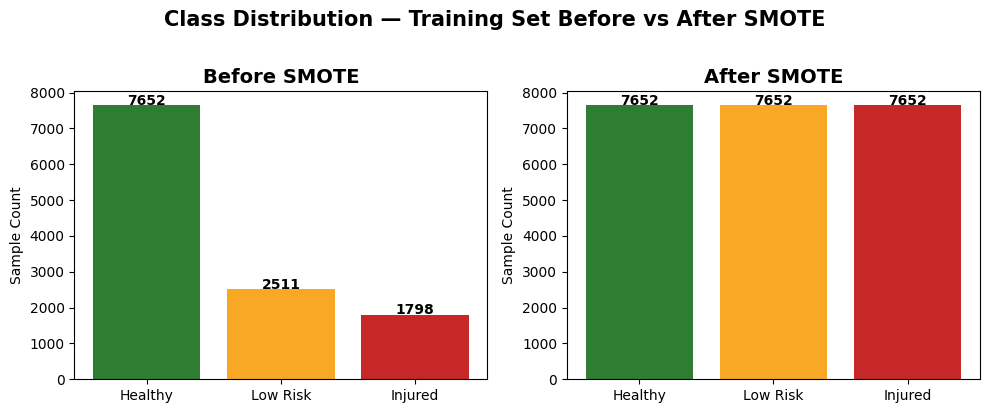

Plot saved to data/processed/smote_class_balance.png


In [21]:
# After state + plot

after_series = pd.Series(y_train_sm)
after_counts = after_series.value_counts().sort_index()
after_pct = after_series.value_counts(normalize=True).sort_index().round(4)

print("Class distribution AFTER SMOTE:")
print(pd.concat([after_counts.rename("count"), after_pct.rename("pct")], axis=1))
print(f"\nTotal training samples after SMOTE: {len(y_train_sm)}")

# Color scheme: green=Healthy, amber=Low Risk, red=Injured
CLASS_LABELS = {0: "Healthy", 1: "Low Risk", 2: "Injured"}
PALETTE = ["#2e7d32", "#f9a825", "#c62828"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before
axes[0].bar(
    [CLASS_LABELS[k] for k in before_counts.index], before_counts.values, color=PALETTE
)
axes[0].set_title("Before SMOTE", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Sample Count")
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# After
axes[1].bar(
    [CLASS_LABELS[k] for k in after_counts.index], after_counts.values, color=PALETTE
)
axes[1].set_title("After SMOTE", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Sample Count")
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 10, str(v), ha="center", fontweight="bold")

fig.suptitle(
    "Class Distribution — Training Set Before vs After SMOTE",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "smote_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to data/processed/smote_class_balance.png")

## Section 8 — Save Artifacts

Everything saved here is what notebook 03, the FastAPI backend, and the React frontend run on.

In [22]:
# Save processed arrays

X_train_sm = np.array(X_train_sm)
y_train_sm = np.array(y_train_sm)

print(f"X_train_sm dtype: {X_train_sm.dtype}  type: {type(X_train_sm)}")
print(f"y_train_sm dtype: {y_train_sm.dtype}  type: {type(y_train_sm)}")

np.savez(
    PROCESSED_DIR / "processed_data.npz",
    X_train=X_train_sm,
    X_test=X_test_scaled.values,  # numpy array, not DataFrame
    y_train=y_train_sm,
    y_test=y_test.values,
)

print(f"Saved: {(PROCESSED_DIR / 'processed_data.npz').resolve()}")

X_train_sm dtype: float64  type: <class 'numpy.ndarray'>
y_train_sm dtype: int64  type: <class 'numpy.ndarray'>
Saved: /home/aztrek/Fortis/data/processed/processed_data.npz


In [23]:
# Save preprocessing objects
joblib.dump(imputer, MODELS_DIR / "knn_imputer.joblib")
joblib.dump(scaler, MODELS_DIR / "standard_scaler.joblib")

print(f"Saved: {(MODELS_DIR / 'knn_imputer.joblib').resolve()}")
print(f"Saved: {(MODELS_DIR / 'standard_scaler.joblib').resolve()}")

Saved: /home/aztrek/Fortis/models/knn_imputer.joblib
Saved: /home/aztrek/Fortis/models/standard_scaler.joblib


In [24]:
# Save feature columns schema
schema = {
    "feature_columns": FEATURE_COLUMNS,
    "n_features": len(FEATURE_COLUMNS),
    "classes": {"0": "Healthy", "1": "Low Risk", "2": "Injured"},
    "rolling_features": [
        "training_load_roll3",
        "training_load_roll7",
        "acwr",
        "fatigue_roll3",
        "fatigue_roll7",
        "recovery_roll3",
        "recovery_roll7",
    ],
}

with open(PROCESSED_DIR / "model_schema.json", "w") as f:
    json.dump(schema, f, indent=2)

print(f"Saved: {(PROCESSED_DIR / 'model_schema.json').resolve()}")

Saved: /home/aztrek/Fortis/data/processed/model_schema.json


In [25]:
# Verification summary
print("=" * 55)
print("PREPROCESSING PIPELINE — FINAL SUMMARY")
print("=" * 55)
print(f"X_train_sm shape:     {X_train_sm.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")
print(f"y_train_sm shape:     {y_train_sm.shape}")
print(f"y_test shape:         {y_test.shape}")
print(f"Feature count:        {len(FEATURE_COLUMNS)}")
print()
print("Files saved:")
artifacts = [
    PROCESSED_DIR / "processed_data.npz",
    PROCESSED_DIR / "model_schema.json",
    PROCESSED_DIR / "smote_class_balance.png",
    MODELS_DIR / "knn_imputer.joblib",
    MODELS_DIR / "standard_scaler.joblib",
]
for p in artifacts:
    exists = "✓" if p.exists() else "✗ MISSING"
    print(f"  {exists}  {p}")
print("=" * 55)

PREPROCESSING PIPELINE — FINAL SUMMARY
X_train_sm shape:     (22956, 35)
X_test_scaled shape:  (2991, 35)
y_train_sm shape:     (22956,)
y_test shape:         (2991,)
Feature count:        35

Files saved:
  ✓  ../data/processed/processed_data.npz
  ✓  ../data/processed/model_schema.json
  ✓  ../data/processed/smote_class_balance.png
  ✓  ../models/knn_imputer.joblib
  ✓  ../models/standard_scaler.joblib
